# <span style="color: #2BF507; background-color: #024E4C; padding: 15px">Roteiro 6 - Lugar Geométrico das Raízes (<i>Root Locus</i>)</span> 

## Conteúdo
 - 1. Introdução
    - 1.1 Definição
    - 1.2 Motivação
    - 1.3 Aplicações
 - 2. Análise do Lugar Geométrico das Raízes (*Root Locus*)   
    - 2.1 Estabilidade
    - 2.2 Resposta Transitória
    - 2.3 Simulação Computacional
 - 3. Resumo Técnico
 - 4. Projeto Prático
 - 5. Exercício Final

#### Curiosidades
**Alquimia** é uma antiga prática que mistura **ciência**, **arte** e **espiritualidade**, considerada a precursora da **química moderna**.  

Principais **Elementos da Alquimia**: **Fogo**, **Terra**, **Água** e **Ar**.  

**Quintessencial** refere-se à forma mais pura, refinada ou perfeita de algo, representando o seu núcleo ou essência mais elevada.  
Derivado de "quinta-essência" (o quinto elemento na alquimia), o termo descreve algo ideal, exemplar ou característico.  
Sinônimos: principal, puro, excelente, ideal, exemplar e suprassumo.

<h2 style="background-color: #09C8C1; color: #07199C; padding: 15px">
    <b>Introdução</b>
</h2>

### 1.1 Definição

O **Método do Lugar das Raízes** (*root locus*) é uma das ferramentas mais poderosas na Engenharia de Controle. Ele foi criado por **Walter R. Evans**, em 1948.

Esse método serve basicamente para <span style="color: rgb(110, 7, 245);">prever as mudanças de comportamento de um **Sistema Dinâmico** quando o ganho proporcional de um controlador é alterado</span>.

#### Exemplo  
Seja um sistema dinâmico, um drone, um motor ou um termostato, para o qual queremos ajustar algum parâmetro dele: posição, altitude, velocidade etc. O **Lugar das Raízes** desenha no plano complexo o caminho percorrido pelos polos do sistema ao se ajustar o parâmetro em questão.

<img src="rot6_fig2.jpg" alt="Plano s mostrando o lugar das raízes de um sistema de segunda ordem" heigth="250" style="display: block; margin: 0 auto;">  

### 1.2 Motivação

**Exemplo**: Ajuste do controlador para diminuir o tempo de resposta do sistema.

#### Projeto de um sistema clássico: **Circuito RLC em Série**.


#### Sistema Dinâmico
Vamos projetar um sistema de segunda ordem que nos permitirá explorar: **amortecimento**, **frequência natural** e **estabilidade**.  
Consideramos um circuito com um resistor ($R$), um indutor ($L$) e um capacitor ($C$) em série, alimentados por uma tensão de entrada $v_i(t)$.  

<img src="RLC_serie.jfif" alt="A imagem é um diagrama esquemático de um circuito RLC em série, ou seja, um circuito elétrico com um resistor (R), um indutor (L) e um capacitor (C) conectados em série." width="450" style="display: block; margin: 0 auto;">

Nossa **saída de interesse** é a tensão no capacitor $v_C(t)$ e a **entrada** é a tensão da fonte de alimentação, $v_i(t)$.
##### Equacionamento no Domínio do Tempo
Pela Lei das Tensões de Kirchhoff:
$$v_i(t) = L \dfrac{d}{dt}i(t) + Ri(t) + v_c(t)$$

Como $i(t) = C \dfrac{d}{dt}v_c(t)$, substituímos para obter a EDO de segunda ordem:
$$LC \dfrac{d^2}{dt^2}v_c(t) + RC \dfrac{d}{dt}v_c(t) + v_c(t) = v_i(t)$$

##### Função de Transferência (Malha Aberta)
Aplicando a Transformada de Laplace (com condições iniciais nulas):
$$G(s) = \dfrac{V_c(s)}{V_i(s)} = \dfrac{1}{LCs^2 + RCs + 1}$$

Para facilitar a análise de controle, dividimos tudo por $LC$:
$$G(s) = \dfrac{\dfrac{1}{LC}}{s^2 + \dfrac{R}{L}s + \dfrac{1}{LC}}$$

##### Polos da Função de Transferência (F.T.)
* **Malha Aberta**: nesse caso, os polos são facilmente obtidos, tipicamente pela identificação por inspeção da F.T., e não mudam com variações no ganho do sistema.
* **Malha Fechada**: nesse caso, tipicamente, eles não podem ser obtidos sem se fatorar o **polinômio característico do sistema em malha fechada** (denominador da F.T. em malha fechada) e variam com
mudanças no ganho do sistema.  

Tendo como referência o diagrama de blocos mostrado a seguir, vamos obter a F.T. do sistema em malha fechada (sistema equivalente), $\mathbf{T(s)}$.  
<img src="./rot6_fig1.png" alt="Diagrama de blocos de um sistema em malha fechada (realimentação negativa)." width="650" style="display: block; margin: 0 auto;">

Do ramo direto temos a seguinte equação: $$C(s) = E_a(s).K.G(s) \tag 1$$
Do ramo de realimentação temos: $$E_a(s) = R(s) - C(s).H(s) \tag 2$$  
Substituindo a equação (2) na equação (1) temos: $$C(s) = [R(s) - C(s).H(s)].K.G(s)$$  
Logo: $$\boxed{\dfrac{C(s)}{R(s)} = T(s) = \dfrac{K.G(s)}{1+K.G(s).H(s)}}$$

Supondo que as F.T.'s sejam escritas como razões de polinômios fatorados, então temos: $G(s)=\dfrac{N_G(s)}{D_G(s)}$ e $H(s)=\dfrac{N_H(s)}{D_H(s)}$.  
Logo, podemos expressar a F.T. do sistema em malha fechada por: 
$$T(s) = \dfrac{K.N_G(s).D_H(s)}{D_G(s).D_H(s)+K.N_G(s).N_H(s)} \tag 3$$

Portanto, os zeros de $T(s)$ consistem nos zeros de $G(s)$ e dos polos de $H(s)$. Os polos de $T(s)$ não são conhecidos imediatamente e podem mudar com $K$.  

**Exemplo**: Seja um sistema com F.T. original $G(s) = \dfrac{s + 1}{s(s + 2)}$ e F.T. do caminho de realimentação $H(s) = \dfrac{s + 3}{s + 4}$.  
* Análise do sistema em malha fechada  
Usando a equação (3) temos: $T(s) = \dfrac{K. (s + 1).(s + 4)}{[s^3 + (6 + K)s^2 + (8 + 4K)s + 3K]}$.  

Assim, os **zeros** de $\bold{T(s)}$ consistem nos zeros da F.T. do sistema original, $G(s)$ e nos polos da F.T. do caminho de realimentação, $H(s)$.  
Os **polos** de $\bold{T(s)}$ não são conhecidos imediatamente sem fatorar o denominador, e eles são função do ganho do caminho direto, $K$. 

Como a **resposta transitória** e a **estabilidade** do sistema dependem dos polos de $T(s)$, não temos conhecimento do desempenho do sistema a menos que fatoremos o denominador para valores específicos de $K$. 

---

### 1.3 Aplicações

#### Análise de Estabilidade
A utilidade maior do *Locus Root* é indicar se o sistema em análise vai tornar-se **instável** ou não com a **variação do ganho do controlador**.

Se os **ramos do gráfico cruzarem o eixo imaginário** e entrarem no semiplano direito, o sistema **torna-se instável**. O método permite identificar o **ganho crítico** antes do sistema começar a oscilar descontroladamente.


#### Análise da Resposta Transitória
O Lugar das Raízes não diz apenas sobre a estabilidade do sistema dinâmico, mas também como o sistema responde nos instantes das perturbações ou das mudanças do *setpoint*. Através da posição dos **polos da Função de Transferência** no plano complexo, podemos visualizar:
* **Velocidade da Resposta**: Quão rápido o sistema atinge o *setpoint*.
* **Sobresinal** (*Overshoot*): O quanto a resposta "passa do ponto" antes de estabilizar.
* **Tempo de Acomodação**: Quanto tempo a resposta demora para parar de oscilar.

#### Projeto de Controladores
Em vez de ficar tentando valores aleatórios no simulador ("tentativa e erro") para sintonizar o controlador do sistema, pode-se usar o **Lugar das Raízes** para:
* Escolher o **ganho ideal** para satisfazer os requisitos de projeto.
* Decidir se é preciso **adicionar "zeros" ou "polos" extras** (usando compensadores de avanço ou atraso de fase) para "puxar" as raízes para uma zona de melhor desempenho.

#### Visualização de Compromissos (*Trade-offs*)
O método deixa claro que raramente se ganha em tudo. Geralmente, ao aumentar o ganho para tornar o sistema mais rápido (diminuir o **erro de regime estacionário**), acaba-se tornando a resposta do sistema mais oscilatória.

<h2 style="background-color: #09C8C1; color: #07199C; padding: 15px">
    <b>2. Análise do Lugar Geométrico das Raízes (<i>Root Locus</i>)</b>
</h2>

O **Lugar Geométrico das Raízes**, ou simplesmente o **Lugar das Raízes**, é um método matemático gráfico que mostra a trajetória dos polos da **Função de Transferência** do sistema em malha fechada conforme varia-se o ganho $K$ em um sistema de **realimentação unitária** ($H(s)=1$) negativa.  

O rastreamento dos polos (raízes do denominador da F.T. do sistema realimentado) obtido com a variação do ganho $K$, permite uma compreensão **qualitativa** do sistema realimentado, principalmente em termos de **estabilidade** e **resposta transitória** do sistema.  

### 2.1 Estabilidade
* **Estável**: Todos os polos localizados no semi-plano $s$ esquerdo (parte real dos polos negativas).  
* **Instável**: Pelos menos um polo no semi-plano $s$ direito; ou polos repetidos no eixo vertical.  
* **Marginalmente Estável**: Um ou mais polos não repetidos sobre o eixo vertical (sistema oscilante).  

### 2.2 Resposta Transitória  
* **Superamortecida:** Quando os polos são reais e distintos.
* **Amortecimento Crítico:** Quando os polos são reais e iguais.
* **Subamortecida:** Quando os polos são complexos conjugados (causando oscilação).

A equação característica do sistema com realimentação unitária é: $$1 + K \cdot G(s) = 0$$

Para o exemplo anterior, circuito RLC série, os polos dependem diretamente de $R$, $L$ e $C$. Se fixarmos os componentes e variarmos o ganho de malha $K$, os polos se moverão no plano complexo $s$.  

---

### 2.3 Simulação Computacional

Para rodar este *script* usaremos algumas bibliotecas: `numpy`, `matplotlib`, `control` e `ipywidgets`.  
Este *script* foi desenvolvido para funcionar no **Jupyter Notebook** ou no **Google Colab**.

A biblioteca '*Control Systems*' (pacote `control`) tem a função `control.feedback()` usada na interconexão de malha fechada com realimentação, conectando dois blocos de processamento: um processo primário (planta, F.T. do caminho direto) e um processo de realimentação (controlador, F.T. do caminho de realimentação), gerando uma representação unificada do sistema equivalente.

* **Sintaxe**:  
```python
import control as ct

sys_closed = ct.feedback(sys1, sys2=1, sign=-1)
```
 * **Parâmetros**:
   * **sys1**: O sistema de caminho direto (normalmente a planta ou o processo a ser controlado). Aceita `TransferFunction`, `StateSpace` ou valores escalares.  
   * **sys2**: O sistema de caminho de *feedback* (normalmente o controlador). O valor padrão é 1 (realimentação unitária) se omitido. 
   * **sign**: O sinal matemático aplicado ao ciclo de realimentação:  
     * -1: Realimentação negativa (padrão). Calcula $\dfrac{sys1}{1+sys1.sys2}$  
     * +1: Realimentação positiva. Calcula $\dfrac{sys1}{1-sys1.sys2}$  

**Exemplo 1**: O *script* a seguir demonstra como definir uma F.T. de uma planta, aplicar um controlador proporcional e gerar um sistema de malha fechada realimentado (*feedback*), usando as convenções da função `feedback()` do pacote `control` do Python:

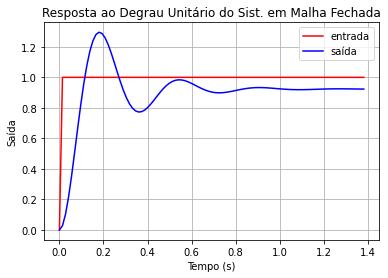

In [6]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

num = [1]; den = [1, 10, 25]                                   # Define F.T. da planta: G(s) = 1 / (s^2 + 10s + 25)
planta = ct.tf(num, den)                                       # Cria a F.T. da planta a ser controlada
controlador = ct.tf([300], [1])                                # Cria a F.T. de um simples controlador Proporcional: K = 300
malha_fechada = ct.feedback(planta * controlador, 1, sign=-1)  # Cria sist. em malha fechada c/ feedback negativo: T(s) = K.G(s) / (1 + K.G(s))
tempo, resposta = ct.step_response(malha_fechada)              # Simula para entrada degrau unitário 
degrau = np.ones(len(tempo)); degrau[0] = 0

# Plota os resultados
plt.plot(tempo, degrau, 'r-', label='entrada')
plt.plot(tempo, resposta, 'b-', label='saída')
plt.title('Resposta ao Degrau Unitário do Sist. em Malha Fechada')
plt.xlabel('Tempo (s)'); plt.ylabel('Saída'); plt.legend(); plt.grid(True); plt.show()

In [ ]:
# ATENÇÂO: Execute essa célula se o seu ambiente Python local não tiver instalado o pacote 'ipywidgets'...
%pip install ipywidgets

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct                                            # biblioteca 'Control Systems'
from ipywidgets import interact, FloatSlider

def plot_rlc_interactive(R, L, C, K):
    num = [1]; den = [L*C, R*C, 1]                              # F.T. do sistema em malha aberta: G(s) = 1 / (L*C*s^2 + R*C*s + 1)
    sys_open = ct.TransferFunction(num, den)
    sys_closed = ct.feedback(K * sys_open, 1)                   # Sist. em malha fechada (real. neg.) e ganho K:  T(s) = K*G(s) / (1 + K*G(s))
    
    fig, (ax_rl, ax_step) = plt.subplots(1, 2, figsize=(12, 4)) # Cria a figura p/ exibição do Lugar das Raízes
    ct.root_locus(sys_open, ax=ax_rl, grid=True, plot=True, ylim=None)     # Gera o gráfico do Lugar das Raízes (Root Locus)
    poles = ct.poles(sys_closed)                                # Calcula e plota os 'polos' para o ganho K escolhido

    ax_rl.plot(np.real(poles), np.imag(poles), 'rX', markersize=10, label=f'Polos com K={K}')
    # # steps for dynamic auto-scaling:
    # ax_rl.relim()                                               # Recalcula os limites dos dados
    # ax_rl.autoscale_view()                                      # Rescala a visão para ajustar os limites aos dados
    # ax_rl.set_ylim(auto=True)
    # plt.gca().axis('auto')
    ax_rl.set_ylim((-6.5,6.5))
    ax_rl.set_title(f'Lugar das Raízes\nPolos: {poles[0]:.2f}, {poles[1]:.2f}')
    ax_rl.legend(); ax_rl.grid(True)

    t, y = ct.step_response(sys_closed)                         # Calcula a resposta ao degrau unitário
    ax_step.plot(t, y, lw=2, color='blue')
    ax_step.axhline(1, color='red', linestyle='--', alpha=0.5)
    ax_step.set_title('Sist. em Malha Fechada - Resposta ao Degrau')
    ax_step.set_xlabel('Tempo (s)'); ax_step.set_ylabel('Vout / Vin')
    ax_step.grid(True); plt.tight_layout(); plt.show()

# Criação dos Widgets Interativos
interact(plot_rlc_interactive, 
         R=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='R (Ω)'),
         L=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='L (H)'),
         C=FloatSlider(value=0.5, min=0.1, max=5.0, step=0.1, description='C (F)'),
         K=FloatSlider(value=1.0, min=0.1, max=20.0, step=0.5, description='Ganho K'));

interactive(children=(FloatSlider(value=2.0, description='R (Ω)', max=10.0, min=0.1), FloatSlider(value=1.0, d…

### Observe na Simulação:
1.  **Aumento de $R$**: Note como os polos se movem para o eixo real (aumentando o amortecimento).
2.  **Aumento de $K$**: Ao aumentar o ganho, os polos tendem a se afastar do eixo real na vertical, o que aumenta a frequência de oscilação e o *overshoot* (sobrepasso) na resposta ao degrau.
3.  **Estabilidade**: Como os polos estão sempre no semiplano esquerdo (parte real negativa) para valores positivos de $R, L, C$, este sistema passivo é intrinsecamente estável.

<h2 style="background-color: #09C8C1; color: #07199C; padding: 15px">
    <b>3. Resumo Técnico</b>
</h2>


Matematicamente, o **Lugar das Raízes** é o conjunto de todos os pontos no plano `s` que satisfazem a **equação característica do sistema** em **malha fechada**:

$$ 1 + K.G(s).H(s) = 0$$

onde: ganho em malha aberta ($K$) varia de 0 a $\infty$. 

O gráfico resultante mostra a trajetória das raízes dessa equação, permitindo que se domine o sistema apenas ajustando o parâmetro K (ganho em malha aberta).

<h2 style="background-color: #09C8C1; color: #07199C; padding: 15px">
    <b>4. Projeto Prático</b>
</h2>

<span  style="color: hsl(178, 94%, 49%);">  

**Projeto Prático** - é onde a teoria do **Lugar das Raízes** (*Root Locus*) realmente mostra seu valor. O primeiro passo é transformar o hardware ou processo em um modelo matemático, por exemplo, via função de transferência ou resposta em frequência.

Roteiro de como aplicar o **Lugar das Raízes** a um projeto prático:

---

### 1. Defina o seu "Plano de Voo"
Antes de mexer no ganho $K$, você precisa saber o que quer. No Lugar das Raízes, isso se traduz em definir uma **região permitida** no plano complexo:
* **Se quer rapidez:** Você busca polos mais à esquerda (maior parte negativa).
* **Se quer evitar oscilação:** Você busca polos próximos ao eixo real (ângulo menor em relação ao eixo horizontal).



### 2. O Fluxo de Projeto
Se o sistema for simples (como um motor DC), o Lugar das Raízes te dirá se um **Controlador P (Proporcional)** resolve. O processo geralmente segue estes passos:

1.  **Obtenha a Planta $G(s)$:** Identifique a função de transferência do seu sistema.
2.  **Plote o Lugar das Raízes:** Use softwares como MATLAB (`rlocus`) ou Python (`control.root_locus`) para ver o desenho.
3.  **Verifique se o "caminho" passa onde você quer:**
    * **Se passar:** Basta escolher o valor de $K$ naquele ponto.
    * **Se NÃO passar:** Você precisará adicionar um **Compensador**.

### 3. Quando o Lugar das Raízes "te obriga" a sofisticar
Às vezes, o desenho das raízes mostra que, por mais que você aumente o ganho, o sistema nunca será rápido o suficiente ou sempre será instável. É aqui que entram os compensadores:

* **Compensador de Avanço** (*Lead*): Ele "puxa" o **Lugar das Raízes** para o semi-plano esquerdo. Serve para aumentar a velocidade e a estabilidade (atua de forma similar à derivada no controlador PID).
* **Compensador de Atraso** (*Lag*): Ele altera o gráfico perto da origem para reduzir o **erro de regime estacionário** sem mudar muito a estabilidade (atua de forma similar à integral no controlador PID).

---

### Dicas para o Projeto Prático:
* **Cuidado com a Saturação**: Na teoria, no método do **Lugar das Raízes** o ganho em malha aberta vai até o infinito. Na prática, se precisarmos de um ganho $K$ gigante para estabilizar o sistema, o motor ou o atuador, pode saturar (ficar sem tensão/corrente suficiente), e o sistema pode tornar-se instável.
* **Discretização**: Para controladores digitais, usando microcontroladores (Arduino, ESP32, STM32 etc.), lembre-se que o **Lugar das Raízes** "clássico" é no plano $s$ (contínuo). Para sistemas digitais com amostragem lenta, o ideal é converter para o plano $z$.
</span>


* **Lugar das Raízes:** Um sistema de 1ª ordem pura **nunca fica instável** com ganho proporcional (os polos apenas correm para a esquerda no eixo real).
* **O problema real:** Quando você adiciona o controlador e sensores, o sistema ganha novos polos (atrasos), e é aí que o **Lugar das Raízes** te mostra o perigo da oscilação crescente (instabilidade).


### 2. Aplicando o Método no seu Caso
Ao projetar o controlador para o motor, observe o seguinte no gráfico:

* **Ganho Proporcional (P):** No gráfico, você verá o polo do motor se movendo para a esquerda. Isso diminui o tempo de resposta (motor mais rápido), mas aumenta o erro de regime (a velocidade real nunca chega exatamente na desejada).
* **Adicionando um Integrador (PI):** Se você quer **erro zero** (velocidade exata), você adiciona um polo na origem $s=0$. 
    * *Cuidado:* Isso "empurra" o Lugar das Raízes para a direita, aproximando o sistema da instabilidade ou causando *overshoot* (a velocidade passa do valor e depois volta).



### 3. Passo a Passo Prático
Se você tiver os parâmetros do motor (Resistência, Indutância, Inércia e Constante de Torque), faça o seguinte:

1.  **Simule a Malha Aberta:** Veja onde os polos estão sem controle.
2.  **Defina o Amortecimento ($\zeta$):** Se você não quer que a velocidade do motor fique oscilando antes de estabilizar, tente manter os polos em um ângulo que garanta $\zeta > 0.707$.
3.  **Ajuste o Ganho no Software:** * No MATLAB: Use `controlSystemDesigner(G)` para arrastar os polos visualmente.
    * No Python: Use `control.root_locus(G)` e observe o ganho $K$ necessário para atingir o tempo de subida desejado.

### 4. O "Pulo do Gato" no Projeto Real
Como é um motor real, fique atento a dois fenômenos que o Lugar das Raízes "puro" não mostra, mas você deve considerar:
* **Zona Morta (Dead-zone):** Tensões muito baixas não vencem o atrito estático.
* **Saturação de Tensão:** Se o seu ganho $K$ calculado for 100, e para um erro de 1 rad/s ele pedir 100V, mas sua fonte for de 12V, o motor não responderá conforme o modelo linear.

**Você já possui os parâmetros do motor (datasheet) ou vai tentar identificar o modelo através de testes experimentais?**
</span>

<h2 style="background-color: #09C8C1; color: #07199C; padding: 15px">
    <b>5. Exercício Final</b>
</h2>

Seja um sistema dado por sua F.T.: $G(s) = \dfrac{1}{s^2+4s+3}$.  
Crie um controlador do tipo compensador, usando um dos quatro tipos de compensação contínua (P, PI, PD ou PID). Use um dicionário com as opções de compensadores disponíveis: P, PI, PD e PID. Experimente alterar o ganho e os parâmetros da planta melhorar a performance do sistema (planta) usado no código:

In [14]:
# Execute esta célula caso sua instalação Python não possua o pacote `control`
%pip install control


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Gabarito

Tipos de compensadores disponíveis: ['P', 'PI', 'PD', 'PID']

Informe os parâmetros do compensador PI:

Compensador selecionado: PI
F.T. do Compensador, H(s):
	Numerador =   [20.0, 5.0] 
	Denominador = [1, 0]
Sistema G(s): <TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      1
-------------
s^2 + 4 s + 3
 
Controlador C(s): <TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


20 s + 5
--------
   s
 
Sistema compensado: <TransferFunction>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


       20 s + 5
----------------------
s^3 + 4 s^2 + 23 s + 5



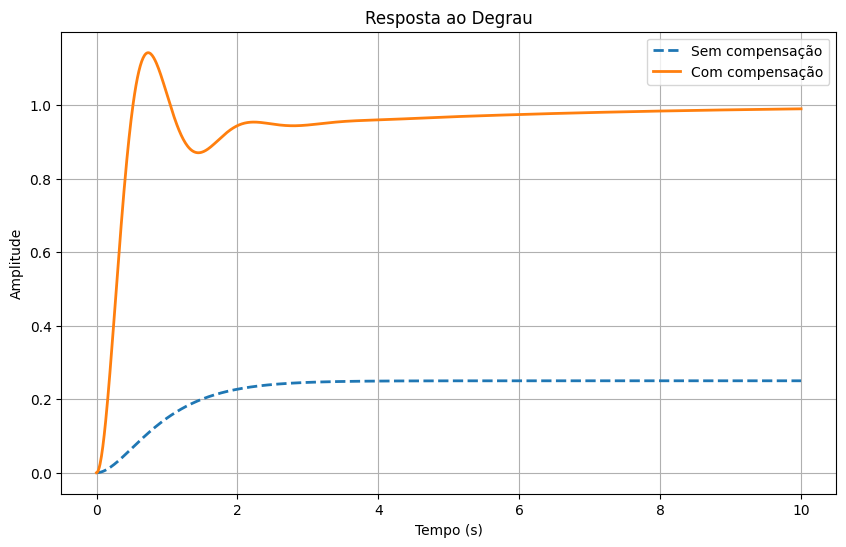

In [16]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

# Dicionário de controladores disponíveis
controladores = {"P": {"num": ["Kp"],"den": [1]}, 
                 "PI": {"num": ["Kp", "Ki"],"den": [1, 0]}, 
                 "PD": {"num": ["Kd", "Kp"],"den": [1]},
                 "PID": {"num": ["Kd", "Kp", "Ki"],"den": [1, 0]}}
print("Tipos de compensadores disponíveis:", list(controladores.keys()))
tipo = input("\nEscolha um controlador: ").upper()
if tipo not in controladores:
    raise ValueError("Tipo de controlador inválido!")

# Entrando os parâmetros do controlador escolhido
num_c = []; den_c = []
print(f"\nInforme os parâmetros do compensador {tipo}:")
for param in controladores[tipo]["num"]:
    valor = float(input(f"{param} = "))
    num_c.append(valor)
for item in controladores[tipo]["den"]:
    if isinstance(item, str):
        valor = float(input(f"{item} = "))
        den_c.append(valor)
    else:
        den_c.append(item)
print("\nCompensador selecionado:", tipo)
print("F.T. do Compensador, H(s):\n\tNumerador =  ", num_c, "\n\tDenominador =", den_c)

G = ct.TransferFunction([1], [1, 4, 3])     # Sistema a ser controlado
C = ct.TransferFunction(num_c, den_c)       # Controlador escolhido
T_sem = ct.feedback(G)                      # Sistema sem compensação (malha fechada)
T_com = ct.feedback(C*G)                    # Sistema compensado (malha fechada)
t = np.linspace(0, 10, 1000)                # Vetor de tempo

# Respostas ao degrau unitário
t1, y1 = ct.step_response(T_sem, t)
t2, y2 = ct.step_response(T_com, t)

# Funções de transferência
print("Sistema G(s):", G, "\nControlador C(s):", C, "\nSistema compensado:", T_com)

# Gráfico
plt.figure(figsize=(10,6))
plt.plot(t1, y1, '--', linewidth=2, label='Sem compensação')
plt.plot(t2, y2,  '-', linewidth=2, label='Com compensação')
plt.title('Resposta ao Degrau'); plt.xlabel('Tempo (s)'); plt.ylabel('Amplitude')
plt.grid(True); plt.legend(); plt.show()

## Fonte(s)

1. Nise, N. S.; "Engenharia de Sistemas de Controle" - 6a. Ed. - Rio de Janeiro: LTC, 2013.
1. Gervasoni, M. D.; "Obtenção da Frequência de PWM a partir do Diagrama de Bode do Motor CC"; UNORP - 18o. CONIC/SEMESP; 2018; 10p; disponível em https://www.conic-semesp.org.br/anais/files/2018/trabalho-1000002402.pdf?1776023730; acesso em 12/04/2026.
1. ALFERINK, F.; "Measuring self-inductance & ESR (equivalent series resistance)"; 26/01/2018; site; disponível em https://meettechniek.info/passive/inductance.html; acesso em 12/04/2026.